<a href="https://colab.research.google.com/github/nishasn10/Aiml_project/blob/main/FP%20Growth_un.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Loaded Successfully!

Dataset Shape:
(134, 2)

Columns:
['aisle_id', 'aisle']

First 10 Rows:
   aisle_id                       aisle
0         1       prepared soups salads
1         2           specialty cheeses
2         3         energy granola bars
3         4               instant foods
4         5  marinades meat preparation
5         6                       other
6         7               packaged meat
7         8             bakery desserts
8         9                 pasta sauce
9        10            kitchen supplies

Missing Values:
aisle_id    0
aisle       0
dtype: int64

Total Transactions:
134

Sample Transactions:
['prepared', 'soups', 'salads']
['specialty', 'cheeses']
['energy', 'granola', 'bars']
['instant', 'foods']
['marinades', 'meat', 'preparation']
['other']
['packaged', 'meat']
['bakery', 'desserts']
['pasta', 'sauce']
['kitchen', 'supplies']

Transaction Matrix:
   accessories    aid    air  allergy  alternatives  appetizers  applesauce  \
0        Fa

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


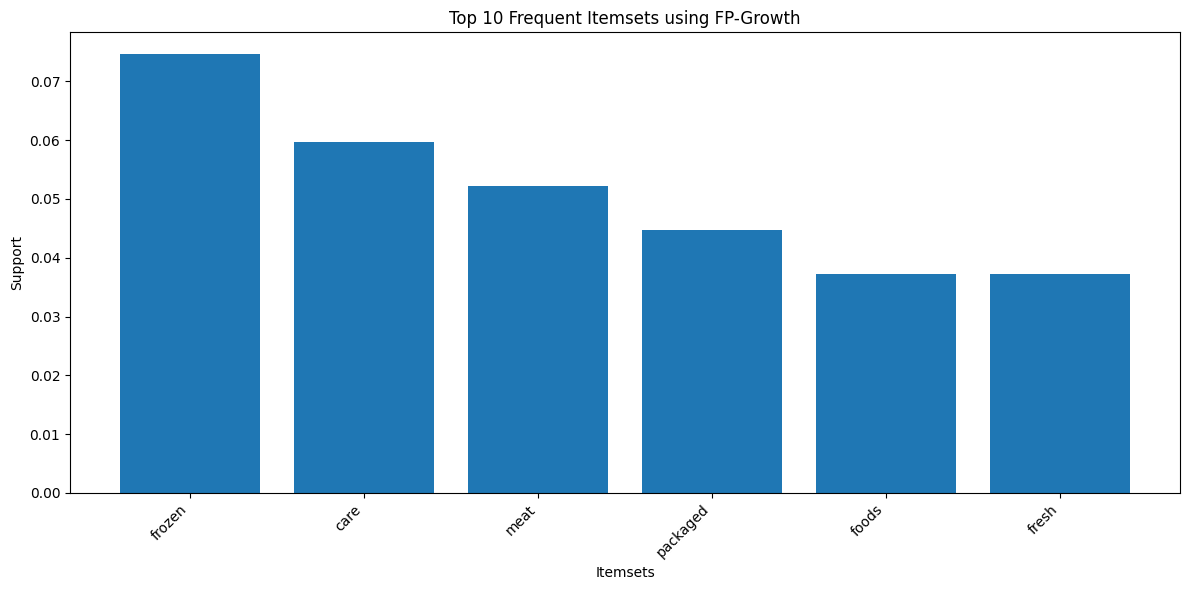


FP-GROWTH COMPLETED
Total Transactions: 134
Frequent Itemsets: 6
Association Rules: 0

Output files created:
1. FP_Growth_Frequent_Itemsets.csv
2. FP_Growth_Association_Rules.csv


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [2]:
# ============================================================
# FP-GROWTH ASSOCIATION RULE MINING
# Aisles Dataset
# Unsupervised Machine Learning
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv("aisles.csv")

print("Dataset Loaded Successfully!")

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 10 Rows:")
print(df.head(10))

# ============================================================
# 2. CHECK MISSING VALUES
# ============================================================

print("\nMissing Values:")
print(df.isnull().sum())

# Remove missing aisle values

df = df.dropna(subset=["aisle"])

# ============================================================
# 3. CREATE TRANSACTIONS
# ============================================================

# Each aisle name is treated as a transaction.
# Words inside an aisle are treated as items.

transactions = []

for value in df["aisle"]:

    items = [
        item.strip().lower()
        for item in str(value).split()
        if item.strip()
    ]

    if len(items) > 0:
        transactions.append(items)

print("\nTotal Transactions:")
print(len(transactions))

print("\nSample Transactions:")
for transaction in transactions[:10]:
    print(transaction)

# ============================================================
# 4. TRANSACTION ENCODING
# ============================================================

te = TransactionEncoder()

encoded_data = te.fit(
    transactions
).transform(
    transactions
)

basket = pd.DataFrame(
    encoded_data,
    columns=te.columns_
)

print("\nTransaction Matrix:")
print(basket.head())

print("\nNumber of Items:")
print(basket.shape[1])

# ============================================================
# 5. APPLY FP-GROWTH
# ============================================================

frequent_itemsets = fpgrowth(
    basket,
    min_support=0.03,
    use_colnames=True
)

# Add item count

frequent_itemsets["item_count"] = (
    frequent_itemsets["itemsets"]
    .apply(len)
)

# Sort by support

frequent_itemsets = frequent_itemsets.sort_values(
    by="support",
    ascending=False
)

# ============================================================
# 6. DISPLAY FREQUENT ITEMSETS
# ============================================================

print("\n======================================")
print("FREQUENT ITEMSETS")
print("======================================")

print(
    frequent_itemsets.head(20)
)

# ============================================================
# 7. GENERATE ASSOCIATION RULES
# ============================================================

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.30
)

# Keep useful rules

rules = rules[
    rules["lift"] > 1
]

# Sort by lift

rules = rules.sort_values(
    by="lift",
    ascending=False
)

print("\n======================================")
print("ASSOCIATION RULES")
print("======================================")

if len(rules) > 0:

    print(
        rules[
            [
                "antecedents",
                "consequents",
                "support",
                "confidence",
                "lift"
            ]
        ].head(20)
    )

else:

    print("No association rules found.")

# ============================================================
# 8. CONVERT ITEMSETS TO STRINGS
# ============================================================

frequent_itemsets["items"] = (
    frequent_itemsets["itemsets"]
    .apply(
        lambda x: ", ".join(sorted(x))
    )
)

if len(rules) > 0:

    rules["antecedents"] = (
        rules["antecedents"]
        .apply(
            lambda x: ", ".join(sorted(x))
        )
    )

    rules["consequents"] = (
        rules["consequents"]
        .apply(
            lambda x: ", ".join(sorted(x))
        )
    )

# ============================================================
# 9. VISUALIZATION 1
# TOP FREQUENT ITEMSETS
# ============================================================

top_itemsets = frequent_itemsets.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_itemsets["items"],
    top_itemsets["support"]
)

plt.xlabel("Itemsets")

plt.ylabel("Support")

plt.title(
    "Top 10 Frequent Itemsets using FP-Growth"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

# ============================================================
# 10. VISUALIZATION 2
# SUPPORT VS CONFIDENCE
# ============================================================

if len(rules) > 0:

    plt.figure(figsize=(9, 6))

    plt.scatter(
        rules["support"],
        rules["confidence"],
        s=60
    )

    plt.xlabel("Support")

    plt.ylabel("Confidence")

    plt.title(
        "FP-Growth Association Rules - Support vs Confidence"
    )

    plt.grid(True)

    plt.show()

# ============================================================
# 11. VISUALIZATION 3
# CONFIDENCE VS LIFT
# ============================================================

if len(rules) > 0:

    plt.figure(figsize=(9, 6))

    plt.scatter(
        rules["confidence"],
        rules["lift"],
        s=60
    )

    plt.xlabel("Confidence")

    plt.ylabel("Lift")

    plt.title(
        "FP-Growth Association Rules - Confidence vs Lift"
    )

    plt.grid(True)

    plt.show()

# ============================================================
# 12. TOP RULES BY LIFT
# ============================================================

if len(rules) > 0:

    top_rules = rules.head(10).copy()

    top_rules["rule"] = (
        top_rules["antecedents"]
        + " → "
        + top_rules["consequents"]
    )

    plt.figure(figsize=(12, 6))

    plt.bar(
        top_rules["rule"],
        top_rules["lift"]
    )

    plt.xlabel("Association Rules")

    plt.ylabel("Lift")

    plt.title(
        "Top 10 Association Rules by Lift"
    )

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.tight_layout()

    plt.show()

# ============================================================
# 13. BEST ASSOCIATION RULE
# ============================================================

if len(rules) > 0:

    best_rule = rules.iloc[0]

    print("\n======================================")
    print("BEST ASSOCIATION RULE")
    print("======================================")

    print(
        "Rule:",
        best_rule["antecedents"],
        "→",
        best_rule["consequents"]
    )

    print(
        "Support:",
        round(best_rule["support"], 4)
    )

    print(
        "Confidence:",
        round(best_rule["confidence"], 4)
    )

    print(
        "Lift:",
        round(best_rule["lift"], 4)
    )

# ============================================================
# 14. SAVE FREQUENT ITEMSETS
# ============================================================

frequent_itemsets.to_csv(
    "FP_Growth_Frequent_Itemsets.csv",
    index=False
)

# ============================================================
# 15. SAVE ASSOCIATION RULES
# ============================================================

if len(rules) > 0:

    rules.to_csv(
        "FP_Growth_Association_Rules.csv",
        index=False
    )

# ============================================================
# 16. FINAL SUMMARY
# ============================================================

print("\n======================================")
print("FP-GROWTH COMPLETED")
print("======================================")

print(
    "Total Transactions:",
    len(transactions)
)

print(
    "Frequent Itemsets:",
    len(frequent_itemsets)
)

print(
    "Association Rules:",
    len(rules)
)

print(
    "\nOutput files created:"
)

print(
    "1. FP_Growth_Frequent_Itemsets.csv"
)

print(
    "2. FP_Growth_Association_Rules.csv"
)